In [1]:
# 02 - making fake SA bank statement PDFs so we can test the pdf extraction
# only need to run this once if reportlab/pdfplumber isnt installed
# !pip install reportlab pdfplumber

In [2]:
from pathlib import Path
import sys, calendar, json
from datetime import date
import numpy as np
import pandas as pd

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import mm
from reportlab.lib.styles import ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer

# use the same cleaning function as notebook 01 (from src/ or this folder)
sys.path += ["../src", "."]
from nlp_preprocessing import clean_description

SEED = 42

# if we are inside the repo use the repo folders, otherwise use my local folders
IN_REPO = Path("../data/processed/test.csv").exists()
BASE = Path(r"C:\Users\This pc")
PROCESSED = Path("../data/processed") if IN_REPO else BASE / "finsight_processed"
OUT_DIR = Path("../data/synthetic_statements") if IN_REPO else BASE / "finsight_statements"
(OUT_DIR / "pdfs").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "ground_truth").mkdir(parents=True, exist_ok=True)

# test split only - the model never saw these rows
test = pd.read_csv(PROCESSED / "test.csv")
print("Test split rows:", len(test))
print("clean_description check:", repr(clean_description("DEBIT ORDER UNISA STUDENT FEES 4521*8876 02 SEP")))
test["category"].value_counts()

Test split rows: 12763
clean_description check: 'unisa student fees'


category
Entertainment     3812
Groceries         3196
Transport         2926
Other Services    2077
Utilities          300
Education          232
Health             220
Name: count, dtype: int64

In [3]:
# 3 made up banks (not real ones so we dont copy any real bank's branding)
# each one has a different layout so we can see if the extractor handles all of them
BANKS = {
    "protea": {   # table with grid lines, dates like "02 Sep", one Amount column with Cr
        "name": "Protea Bank", "colour": "#1F5F4A", "style": "ruled",
        "date_fmt": "%d %b", "columns": ["Date", "Description", "Amount", "Balance"],
        "col_mm": [20, 100, 30, 30],
    },
    "karoo": {    # no lines at all, dd/mm/yyyy, money in / money out, spaces in thousands
        "name": "Karoo Savings Bank", "colour": "#8A3B12", "style": "open",
        "date_fmt": "%d/%m/%Y", "columns": ["Date", "Description", "Money In", "Money Out", "Balance"],
        "col_mm": [24, 84, 24, 24, 24],
    },
    "highveld": { # striped rows, yyyy-mm-dd, debits / credits
        "name": "Highveld Mutual", "colour": "#1F3864", "style": "zebra",
        "date_fmt": "%Y-%m-%d", "columns": ["Date", "Description", "Debits", "Credits", "Balance"],
        "col_mm": [24, 84, 24, 24, 24],
    },
}

# roughly how many transactions per category in a month (our own estimate)
MONTHLY_COUNTS = {"Groceries": 12, "Transport": 8, "Entertainment": 10, "Other Services": 6,
                  "Utilities": 3, "Health": 2, "Education": 1}
DEBIT_ORDER_CATS = {"Utilities", "Health", "Education"}   # these normally go off as debit orders
POS_PREFIXES = ["POS PURCHASE", "CARD PURCHASE", "POS PURCHASE", ""]
DO_PREFIXES = ["DEBIT ORDER", "DEBIT ORDER", "MAGTAPE DEBIT", "INTERNET PMT TO", "EFT PAYMENT"]

CUSTOMERS = ["MR T MOKOENA", "MS L VAN WYK", "MR K NAIDOO", "MS S DLAMINI", "MR A PIETERSEN",
             "MS N MAHLANGU", "MR J BOTHA", "MS P GOVENDER", "MR S NKOSI", "MS R SMITH"]
EMPLOYERS = ["ACACIA LOGISTICS", "MOTSWEDI HOLDINGS", "BLUE CRANE SYSTEMS", "IMPALA RETAIL GROUP",
             "SUNVELD ENGINEERING", "BAOBAB CONSULTING"]
STATEMENT_MONTHS = [(2026, m) for m in range(4, 10)]   # april to september 2026
N_STATEMENTS = 30                                      # 10 per bank

In [4]:
# builds one month of transactions for one customer
# this is also the "answer sheet" (ground truth) we check the extractor against later
def build_statement(stmt_id, bank_key, year, month, pool, rng):
    n_days = calendar.monthrange(year, month)[1]
    rows = []

    def add(day, text, amount, category, is_spend, source, expected=None):
        text = " ".join(text.split())
        rows.append({"day": int(day), "description_pdf": text,
                     # for test rows keep the original text so we can check the cleaning later
                     "description_sa": expected if expected is not None else clean_description(text),
                     "amount": round(float(amount), 2), "category": category,
                     "is_spend": is_spend, "source": source})

    # salary comes in on the 25th
    add(25, f"SALARY {rng.choice(EMPLOYERS)}", round(rng.uniform(15_000, 45_000), -2), "Income", False, "generated")

    # spending - take rows from the test split and remove them so nothing is used twice
    for cat, lam in MONTHLY_COUNTS.items():
        for _ in range(max(1 if cat != "Education" else 0, rng.poisson(lam))):
            if not pool[cat]:
                break
            r = pool[cat].pop()
            # debit orders mostly early in the month, card purchases any day
            if cat in DEBIT_ORDER_CATS and rng.random() < 0.6:
                day, prefix = rng.integers(1, 8), rng.choice(DO_PREFIXES)
            else:
                day, prefix = rng.integers(1, n_days + 1), rng.choice(POS_PREFIXES)
            # add card numbers / dates like real statements have (the cleaner removes these)
            noise = ""
            if rng.random() < 0.5:
                noise += f" {rng.integers(1000, 9999)}*{rng.integers(1000, 9999)}"
            if rng.random() < 0.3:
                noise += f" {date(year, month, int(day)).strftime('%d %b').upper()}"
            add(day, f"{prefix} {r['description_sa'].upper()}{noise}", -abs(r["amount_zar"]), cat, True,
                "test_split", expected=r["description_sa"])

    # monthly bank fee + sometimes a transfer to savings
    add(n_days, "MONTHLY ACCOUNT FEE", -float(rng.choice([65, 69, 75, 99])), "Other Services", True, "generated")
    if rng.random() < 0.6:
        add(26, "TRANSFER TO SAVINGS", -round(rng.uniform(500, 3_000), -2), "Transfer", False, "generated")

    # sort by day (random order if same day)
    df = pd.DataFrame(rows)
    df["order"] = rng.permutation(len(df))
    df = df.sort_values(["day", "order"]).drop(columns="order").reset_index(drop=True)
    df["date"] = [date(year, month, d) for d in df["day"]]

    # opening balance = enough to last until payday + a bit extra
    # some people (about 15%) go into overdraft so we also test negative balances
    lowest_point = df["amount"].cumsum().min()
    buffer = rng.uniform(200, 6_000) - (2_500 if rng.random() < 0.15 else 0)
    opening = round(max(0.0, -lowest_point) + buffer, 2)
    df["balance"] = (opening + df["amount"].cumsum()).round(2)
    df.insert(0, "statement_id", stmt_id)
    df.insert(1, "row_no", range(1, len(df) + 1))

    meta = {"statement_id": stmt_id, "bank": bank_key, "bank_name": BANKS[bank_key]["name"],
            "layout": BANKS[bank_key]["style"], "customer": str(rng.choice(CUSTOMERS)),
            "account_no": f"{rng.integers(10**9, 10**10)}",
            "period_start": date(year, month, 1).isoformat(), "period_end": date(year, month, n_days).isoformat(),
            "opening_balance": opening, "closing_balance": float(df["balance"].iloc[-1]),
            "n_transactions": len(df)}
    cols = ["statement_id", "row_no", "date", "description_pdf", "description_sa", "amount", "balance",
            "category", "is_spend", "source"]
    return df[cols], meta

In [5]:
# money formats are different per bank
def fmt_money(x, bank_key, kind):
    if bank_key == "protea":                                  # 1,234.56 and 1,234.56Cr
        if kind == "amount":
            return f"{abs(x):,.2f}" + ("Cr" if x > 0 else "")
        return f"{abs(x):,.2f}" + ("Cr" if x >= 0 else "Dr")
    if bank_key == "karoo":                                   # 1 234.56 and -1 234.56
        return f"{x:,.2f}".replace(",", " ")
    return f"{x:,.2f}"                                        # highveld: 1,234.56

DESC_STYLE = ParagraphStyle("desc", fontName="Helvetica", fontSize=8, leading=10)

# turns the dataframe into table rows for the pdf
def table_rows(df, meta):
    b = BANKS[meta["bank"]]
    first_day = date.fromisoformat(meta["period_start"]).strftime(b["date_fmt"])
    rows = [b["columns"]]
    opening = meta["opening_balance"]
    if meta["bank"] == "protea":
        rows.append([first_day, "BALANCE BROUGHT FORWARD", "", fmt_money(opening, "protea", "balance")])
        for r in df.itertuples():
            rows.append([r.date.strftime(b["date_fmt"]), Paragraph(r.description_pdf, DESC_STYLE),
                         fmt_money(r.amount, "protea", "amount"), fmt_money(r.balance, "protea", "balance")])
    else:
        rows.append([first_day, "OPENING BALANCE", "", "", fmt_money(opening, meta["bank"], "balance")])
        for r in df.itertuples():
            money_in = fmt_money(r.amount, meta["bank"], "in") if r.amount > 0 else ""
            money_out = fmt_money(r.amount if meta["bank"] == "karoo" else -r.amount, meta["bank"], "out") if r.amount < 0 else ""
            cells = [money_in, money_out] if meta["bank"] == "karoo" else [money_out, money_in]  # highveld is debits first
            rows.append([r.date.strftime(b["date_fmt"]), Paragraph(r.description_pdf, DESC_STYLE),
                         *cells, fmt_money(r.balance, meta["bank"], "balance")])
    return rows

# draws the actual pdf with reportlab
def render_pdf(df, meta, path):
    b = BANKS[meta["bank"]]
    colour = colors.HexColor(b["colour"])
    doc = SimpleDocTemplate(str(path), pagesize=A4, leftMargin=15*mm, rightMargin=15*mm,
                            topMargin=15*mm, bottomMargin=18*mm,
                            title=f"{b['name']} statement {meta['statement_id']}", author=b["name"])
    h = ParagraphStyle("h", fontName="Helvetica-Bold", fontSize=16, textColor=colour, leading=20)
    s = ParagraphStyle("s", fontName="Helvetica", fontSize=9, leading=12)
    # top part of the statement
    story = [
        Paragraph(b["name"], h),
        Paragraph("Statement of Account", s),
        Spacer(1, 4*mm),
        Paragraph(f"<b>Account holder:</b> {meta['customer']}", s),
        Paragraph(f"<b>Account number:</b> ******{meta['account_no'][-4:]}", s),
        Paragraph(f"<b>Statement period:</b> {meta['period_start']} to {meta['period_end']}", s),
        Paragraph(f"<b>Opening balance:</b> R {meta['opening_balance']:,.2f} &nbsp;&nbsp; "
                  f"<b>Closing balance:</b> R {meta['closing_balance']:,.2f}", s),
        Spacer(1, 5*mm),
    ]
    # transactions table (header repeats on every page)
    t = Table(table_rows(df, meta), colWidths=[w*mm for w in b["col_mm"]], repeatRows=1)
    style = [
        ("FONT", (0, 0), (-1, 0), "Helvetica-Bold", 8),
        ("FONT", (0, 1), (-1, -1), "Helvetica", 8),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("BACKGROUND", (0, 0), (-1, 0), colour),
        ("ALIGN", (2, 0), (-1, -1), "RIGHT"),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ]
    if b["style"] == "ruled":
        style += [("GRID", (0, 0), (-1, -1), 0.4, colors.grey)]
    elif b["style"] == "open":
        style += [("LINEBELOW", (0, 0), (-1, 0), 0.8, colour)]
    else:
        style += [("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#EEF2F8")])]
    t.setStyle(TableStyle(style))
    story.append(t)

    # footer on every page so nobody thinks its a real statement
    def footer(canvas, doc_):
        canvas.saveState()
        canvas.setFont("Helvetica", 7)
        canvas.setFillColor(colors.grey)
        canvas.drawString(15*mm, 10*mm, "SYNTHETIC TEST DOCUMENT - FINSIGHT (ITDPA3-34). NOT A REAL BANK STATEMENT.")
        canvas.drawRightString(A4[0] - 15*mm, 10*mm, f"Page {doc_.page}")
        canvas.restoreState()

    doc.build(story, onFirstPage=footer, onLaterPages=footer)

In [6]:
# make all 30 statements + save the ground truth csv for each one
gen_rng = np.random.default_rng(SEED)
shuffled = test.sample(frac=1, random_state=SEED)
pool = {cat: g.to_dict("records") for cat, g in shuffled.groupby("category")}

bank_keys = list(BANKS)
index_rows, all_truth = [], []
for i in range(N_STATEMENTS):
    stmt_id = f"STMT{i+1:03d}"
    bank_key = bank_keys[i % len(bank_keys)]
    year, month = STATEMENT_MONTHS[gen_rng.integers(len(STATEMENT_MONTHS))]
    df, meta = build_statement(stmt_id, bank_key, year, month, pool, gen_rng)

    pdf_path = OUT_DIR / "pdfs" / f"{stmt_id}_{bank_key}.pdf"
    gt_path = OUT_DIR / "ground_truth" / f"{stmt_id}_{bank_key}.csv"
    render_pdf(df, meta, pdf_path)
    df.to_csv(gt_path, index=False)

    meta.update(pdf_file=pdf_path.name, ground_truth_file=gt_path.name)
    index_rows.append(meta)
    all_truth.append(df)

index = pd.DataFrame(index_rows)
truth = pd.concat(all_truth, ignore_index=True)
index.to_csv(OUT_DIR / "statements_index.csv", index=False)
truth.to_csv(OUT_DIR / "ground_truth_all.csv", index=False)

print(f"Generated {len(index)} statements, {len(truth):,} transactions -> {OUT_DIR}")
display(index.groupby("bank_name")[["n_transactions"]].agg(["count", "mean", "min", "max"]).round(1))
truth["category"].value_counts()

Generated 30 statements, 1,341 transactions -> C:\Users\This pc\finsight_statements


n_transactions              
                            count  mean min max
bank_name                                      
Highveld Mutual                10  45.3  33  55
Karoo Savings Bank             10  44.6  35  64
Protea Bank                    10  44.2  31  50

category
Groceries         390
Entertainment     294
Other Services    214
Transport         212
Utilities         102
Health             56
Income             30
Education          24
Transfer           19
Name: count, dtype: int64

In [7]:
# checks
# 1. opening balance + all amounts should equal the closing balance
recon_ok = all(
    np.isclose(g["balance"].iloc[-1], m.opening_balance + g["amount"].sum())
    for (sid, g), m in zip(truth.groupby("statement_id"), index.itertuples())
)
print("Balances reconcile:", recon_ok)

# 2. cleaning the pdf text should give back the exact test split text
spend_rows = truth[truth["source"] == "test_split"]
back = spend_rows["description_pdf"].map(clean_description)
print(f"Clean round-trip matches: {(back == spend_rows['description_sa']).mean():.1%} of {len(spend_rows):,} rows")

# 3. no test row should be used twice
print("Test rows used:", len(spend_rows), "| still unused:", sum(len(v) for v in pool.values()))
truth.sample(8, random_state=1)[["statement_id", "date", "description_pdf", "amount", "balance", "category"]]

Balances reconcile: True
Clean round-trip matches: 100.0% of 1,262 rows
Test rows used: 1262 | still unused: 11501


,statement_id,date,description_pdf,amount,balance,category
808,STMT018,2026-09-17,ATM FEE DURBAN 5074*3917 17 SEP,-96.96,7787.97,Other Services
248,STMT005,2026-06-30,CARD PURCHASE CHECKERS COM 5218*8457,-329.63,14571.67,Groceries
693,STMT016,2026-04-05,CARD PURCHASE SP TOADANDCO HTTPSTOADANDCCA 479...,-1148.65,15532.67,Other Services
1136,STMT026,2026-07-16,POS PURCHASE VILLAGE MARKET MENLYN 16 JUL,-168.54,9644.25,Groceries
311,STMT007,2026-06-14,POS PURCHASE CHECKERS FLAGSTAFF,-278.17,9235.80,Groceries
940,STMT021,2026-09-14,FSI ESKOM LOCAL 14 SEP,-275.59,7232.96,Utilities
408,STMT009,2026-04-14,POS PURCHASE TIME PM DATE CHECKERS SUPER CELEX...,-577.92,5746.51,Groceries
1093,STMT025,2026-07-08,SPAR SUP,-204.47,8200.10,Groceries


STMT003_highveld.pdf - 2 pages


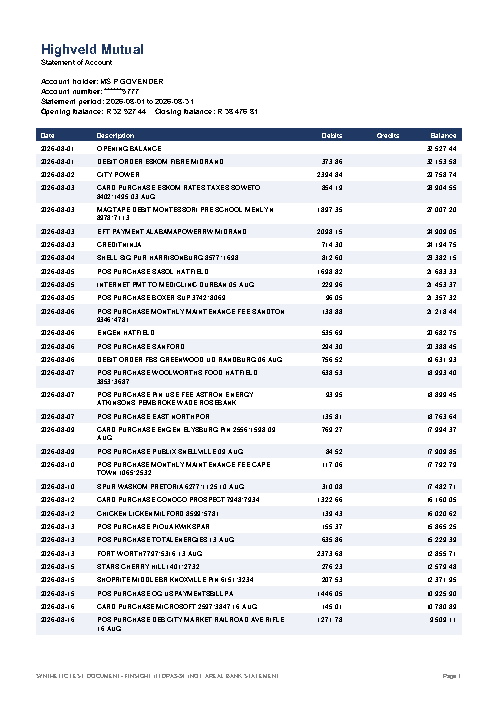

STMT002_karoo.pdf - 2 pages


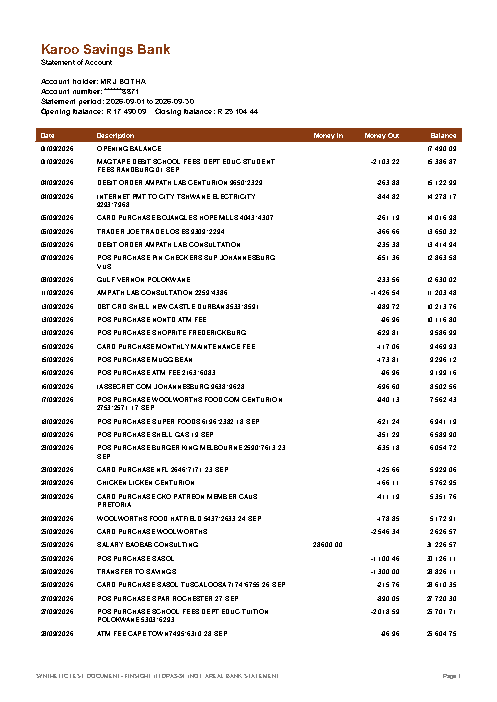

STMT001_protea.pdf - 2 pages


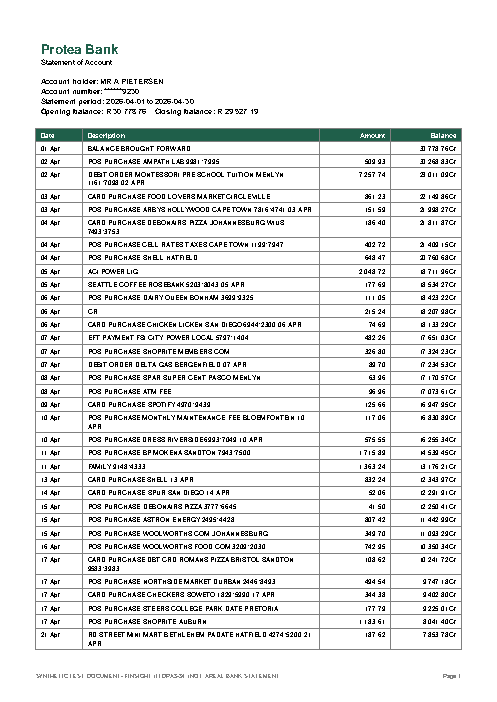

In [8]:
# quick look at page 1 of each bank
import pdfplumber
for f in index.groupby("bank")["pdf_file"].first():
    with pdfplumber.open(OUT_DIR / "pdfs" / f) as pdf:
        print(f, "-", len(pdf.pages), "pages")
        display(pdf.pages[0].to_image(resolution=60))